# Predicting Customer Churn for an Online E-Commerce Company

# Business Background
The dataset comes from a leading online e-commerce company. The company aims to identify customers who are likely to churn so that they can proactively engage these customers with targeted promotions or retention strategies. Accurate churn prediction allows the company to optimize marketing efforts, reduce customer attrition, and enhance overall customer lifetime value.

In [2]:
# data processing 
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# data pre-processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
import sklearn.metrics 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)


# models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# "Set2" palette
from cycler import cycler
colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)


#
import warnings
warnings.filterwarnings('ignore')

# Data Processing

## Data Source：
Data source:https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

## Data Description
The dataset contains 5,630 records and 20 features related to customer behavior, demographics, and transaction history. The following table summarizes each feature:
| Column Name                 | Data Type | Description                                                                           |
| --------------------------- | --------- | ------------------------------------------------------------------------------------- |
| CustomerID                  | int64     | Unique identifier for each customer.                                                  |
| Churn                       | int64     | Target variable indicating whether the customer churned (1) or not (0).               |
| Tenure                      | float64   | Number of months the customer has been with the company.                              |
| PreferredLoginDevice        | object    | Device most frequently used by the customer to log in (e.g., Mobile, Desktop).        |
| CityTier                    | int64     | Tier of the city where the customer resides, typically indicating urbanization level. |
| WarehouseToHome             | float64   | Distance from the warehouse to the customer’s home (in kilometers).                   |
| PreferredPaymentMode        | object    | Customer's most frequently used payment method (e.g., Credit Card, COD).              |
| Gender                      | object    | Gender of the customer.                                                               |
| HourSpendOnApp              | float64   | Average hours spent by the customer on the app per week.                              |
| NumberOfDeviceRegistered    | int64     | Number of devices the customer has registered for the account.                        |
| PreferedOrderCat            | object    | Customer’s preferred product category.                                                |
| SatisfactionScore           | int64     | Customer satisfaction score (e.g., 1–5).                                              |
| MaritalStatus               | object    | Marital status of the customer.                                                       |
| NumberOfAddress             | int64     | Number of addresses registered by the customer.                                       |
| Complain                    | int64     | Number of complaints filed by the customer.                                           |
| OrderAmountHikeFromlastYear | float64   | Increase in order amount compared to the previous year.                               |
| CouponUsed                  | float64   | Number of coupons used by the customer.                                               |
| OrderCount                  | float64   | Total number of orders placed by the customer.                                        |
| DaySinceLastOrder           | float64   | Number of days since the customer’s last order.                                       |
| CashbackAmount              | float64   | Total cashback amount received by the customer.                                       |


# Data Cleaning

In [22]:
df = pd.read_excel("E Commerce Dataset.xlsx",sheet_name = 1)
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [23]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
# 
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5630.0,10.134103,8.357951,0.0,3.00,9.00,15.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5630.0,15.566785,8.345961,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5630.0,2.934636,0.705528,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


# EDA

First, we take a look at the dataset and review its basic information, including key variables and data structure.

In [25]:
df.Churn.value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

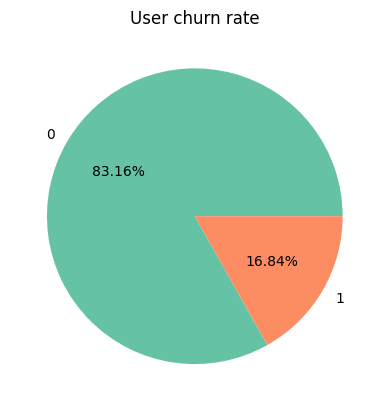

In [26]:
plt.pie(df.Churn.value_counts(),
       labels=[0,1],
       autopct="%.2f%%")
plt.title("User churn rate")
plt.show()

This is an imbalanced class scenario.

The user churn rate is 16.84%. At the data modeling stage, this dataset is considered imbalanced. To improve the performance of machine learning models, **oversampling** is applied to balance the dataset.

In [27]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Churn Analysis by User Attributes

These visualizations aim to compare the distribution of key user attributes between churned (1) and retained (0) users, helping to identify which features may be associated with customer churn.

**Gender Distribution**: reveals potential gender differences in churn behavior.

**Order Count**: examines whether purchase frequency affects churn likelihood.

**Login Device**: shows if users on different devices (e.g., mobile vs. desktop) have distinct churn patterns.

**Preferred Payment Mode**: explores how payment preferences relate to user retention.

Together, these analysis provide an initial understanding of churn-related behavioral patterns, offering insights for further modeling or targeted retention strategies.

### Gender Distribution

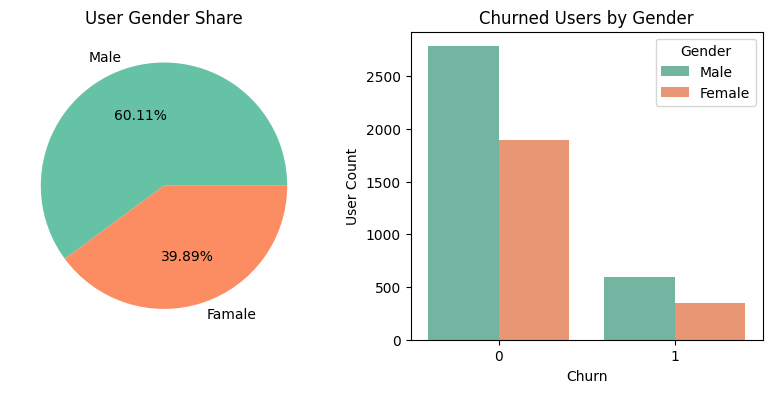

In [9]:
#Gender
plt.figure(figsize=(10,2*2))

plt.subplot(121)
plt.pie(df.Gender.value_counts(),
       labels=['Male','Famale'],
       autopct='%.2f%%')
plt.title('User Gender Share')

plt.subplot(122)
sns.countplot(x = df.Churn,
             hue = df.Gender,
             )
plt.title('Churned Users by Gender')
plt.ylabel('User Count')

plt.show()

In the figures above, the first chart shows that the proportion of male users is higher than that of female users. However, in the second chart, the gender distribution of churned users suggests that user churn is not strongly related to gender.

### Order Count

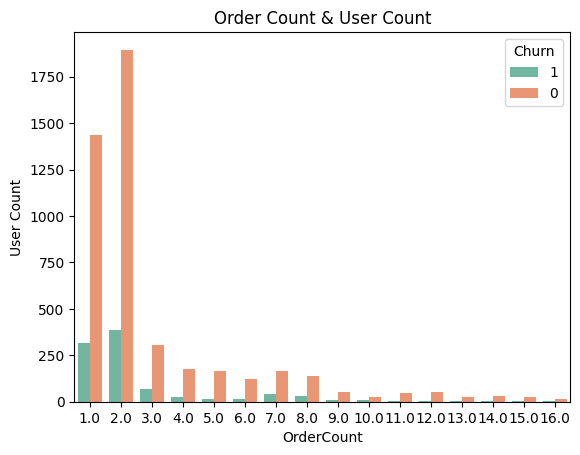

In [10]:
#Ordercount
sns.countplot(x = df.OrderCount,
             hue = df.Churn.astype(str))
plt.ylabel('User Count')
plt.title('Order Count & User Count')
plt.show()

Churn is higher among users with fewer orders and those with 7–8 orders. This may reflect poor product experience and low user stickiness, suggesting the need to improve product experience to reduce churn.

### Login Device

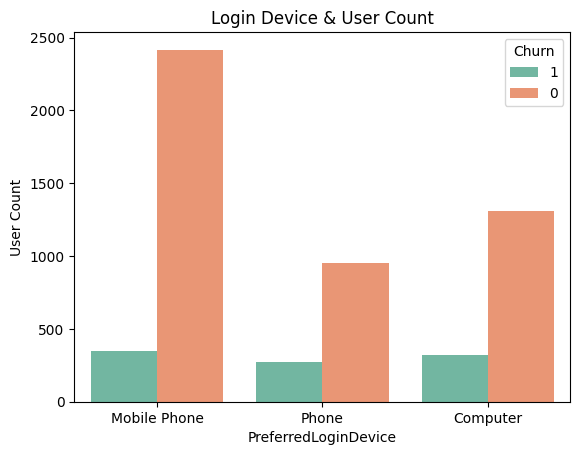

In [11]:
#Login Device
sns.countplot(x = df.PreferredLoginDevice,
             hue = df.Churn.astype(str))
plt.ylabel('User Count')
plt.title('Login Device & User Count')
plt.show()

From the above chart, it can be seen that the number of churned users is not strongly related to the login device. Regardless of the device used, there is no significant difference in the number of churned users. However, when looking at the churn rate roughly, users logging in via Phone have a higher churn rate. With the same number of churned users, a smaller overall user base leads to a higher churn rate; the churn rate for Computer users is also relatively high. Therefore, it is necessary for operations and maintenance teams to optimize the user experience for these two devices to reduce churn.

### Preferred Payment Mode

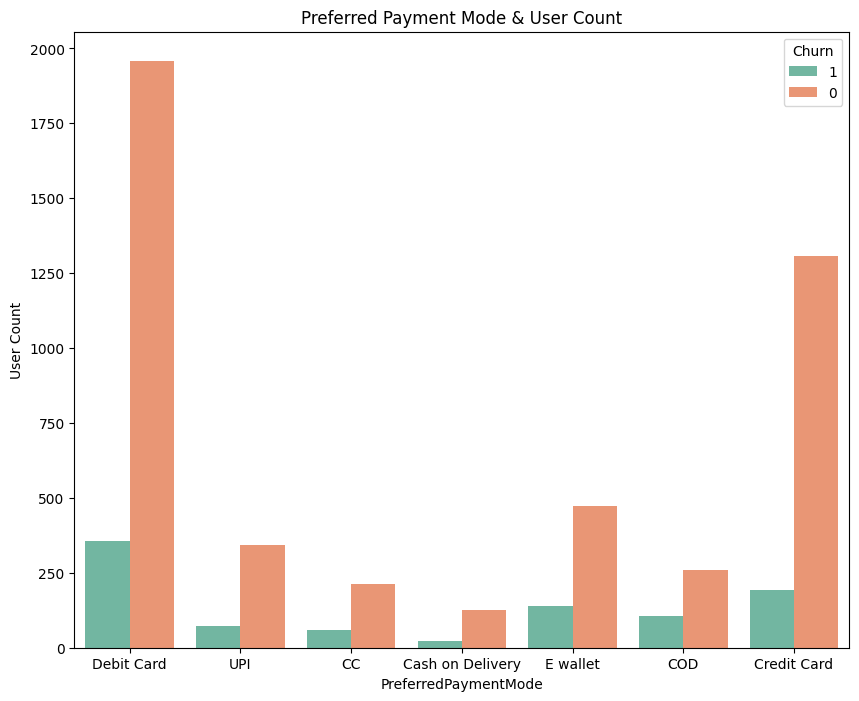

In [12]:
#Preferred Payment Mode
plt.figure(figsize=(10,8))
sns.countplot(x = df.PreferredPaymentMode,
             hue = df.Churn.astype(str))
plt.ylabel('User Count')
plt.title('Preferred Payment Mode & User Count')
plt.show()

The top three payment methods used by users are **Debit Card**, **Credit Card**, and **E-wallet**. Since users of these three methods account for a large proportion, relevant operations teams can focus on improving the user experience for these payment methods.

## Feature Distribution Analysis

To understand the overall characteristics of the dataset and identify potential data skewness or feature imbalance, both numerical and categorical variables were analyzed through distribution plots.

In [13]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

### Numerical Features

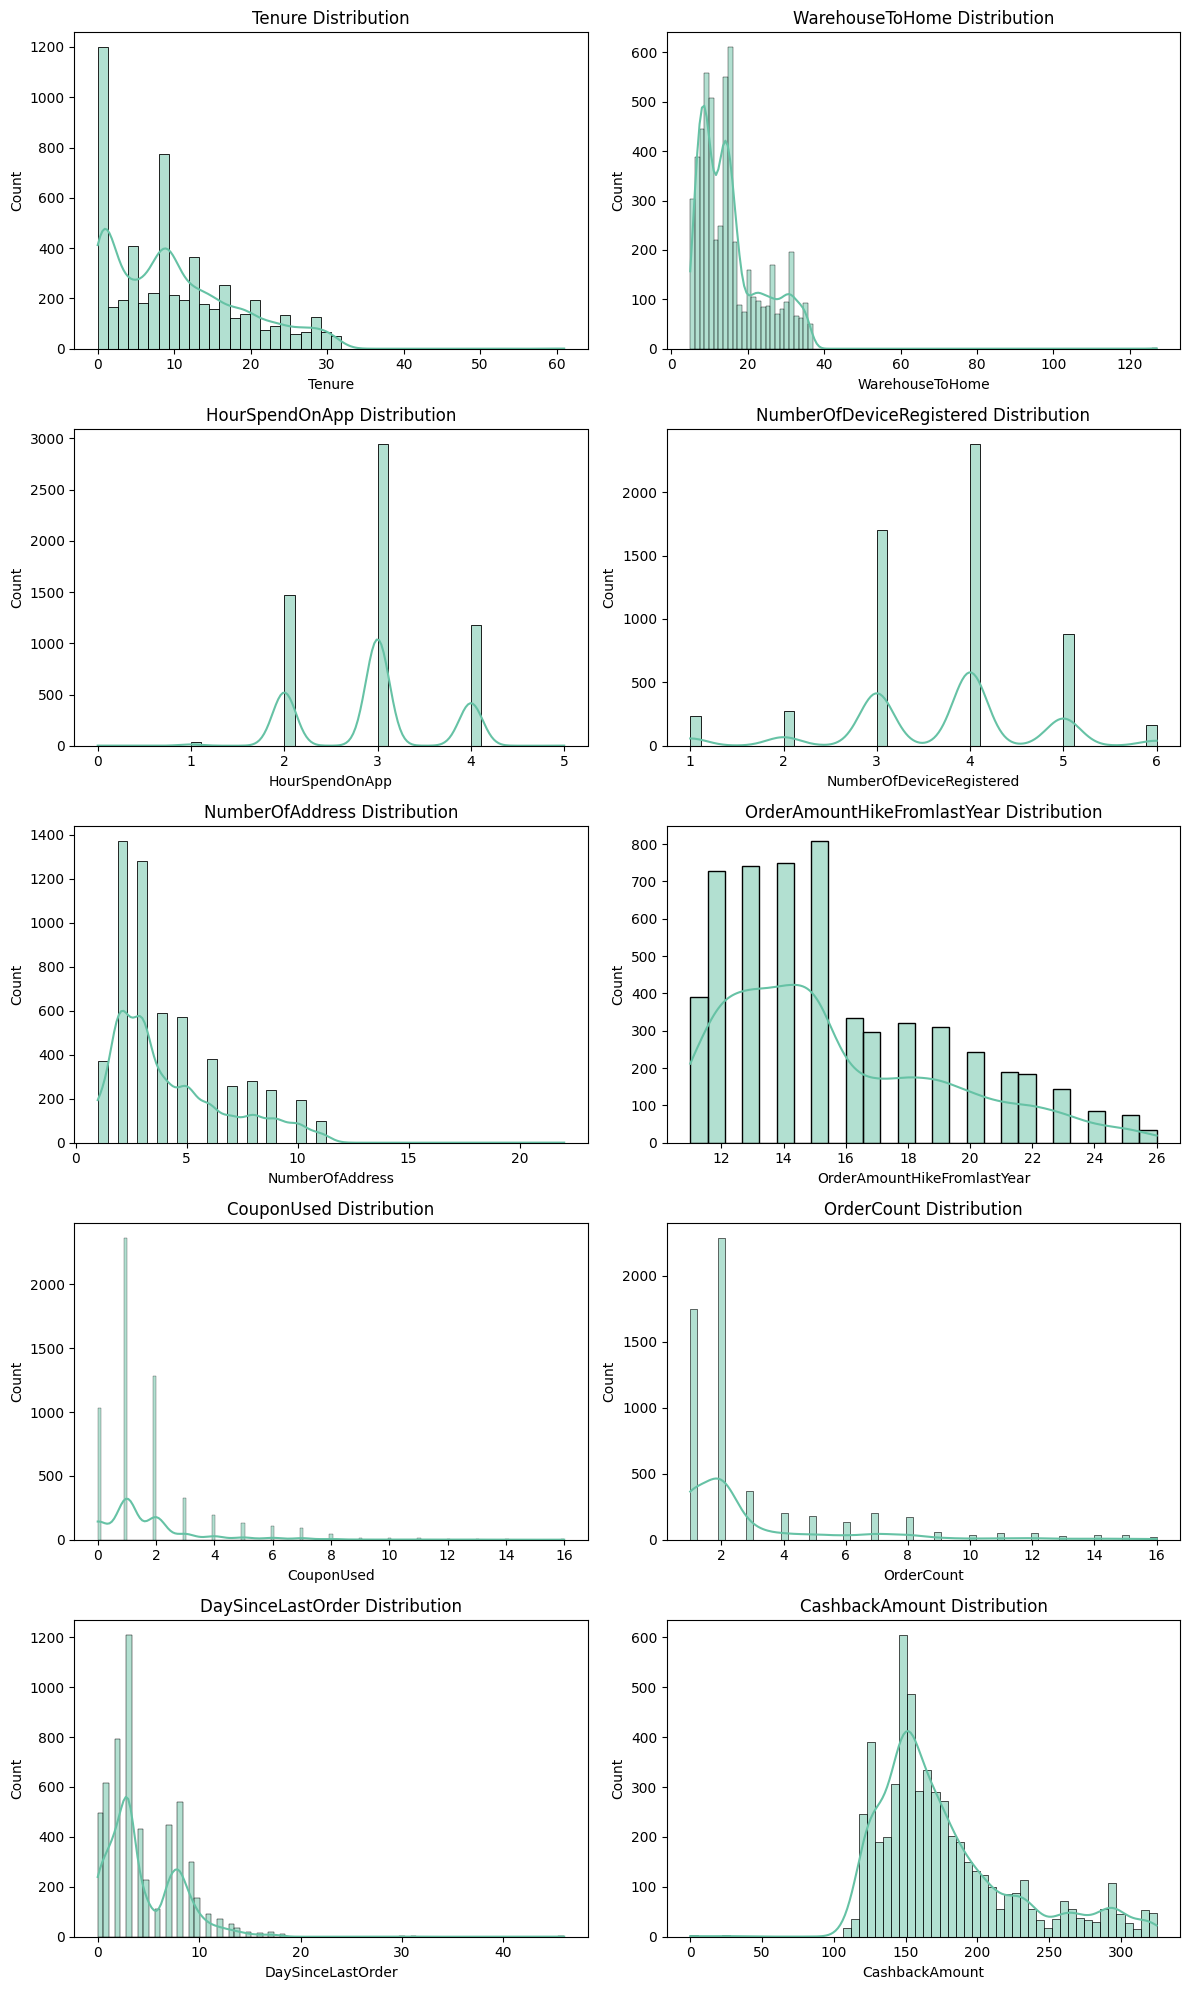

In [14]:
#数值变量
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # 自动计算行数

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
axes = axes.flatten()  # 展平成一维数组，方便循环

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# 删除多余空白子图（如果总数不是行*列的整数倍）
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()


The numerical variables (e.g., Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, OrderCount, CashbackAmount, etc.) exhibit varied distribution patterns:

* Right-skewed distributions are common across most variables such as Tenure, WarehouseToHome, CouponUsed, and OrderCount, indicating that a large portion of users have shorter tenures, live relatively close to warehouses, and make few purchases or use few coupons.

* Multimodal patterns in HourSpendOnApp and NumberOfDeviceRegistered suggest different user segments or behavioral clusters — for instance, some users may use the app briefly while others spend more time engaging.

* CashbackAmount and OrderAmountHikeFromLastYear show relatively smoother distributions but with long tails, implying that a small group of users contributes disproportionately to cashback and spending growth.

* Overall, the skewness of most variables suggests a user base where light and infrequent shoppers dominate, with only a small fraction of highly engaged or high-spending customers.

### Categorical Features

In [15]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

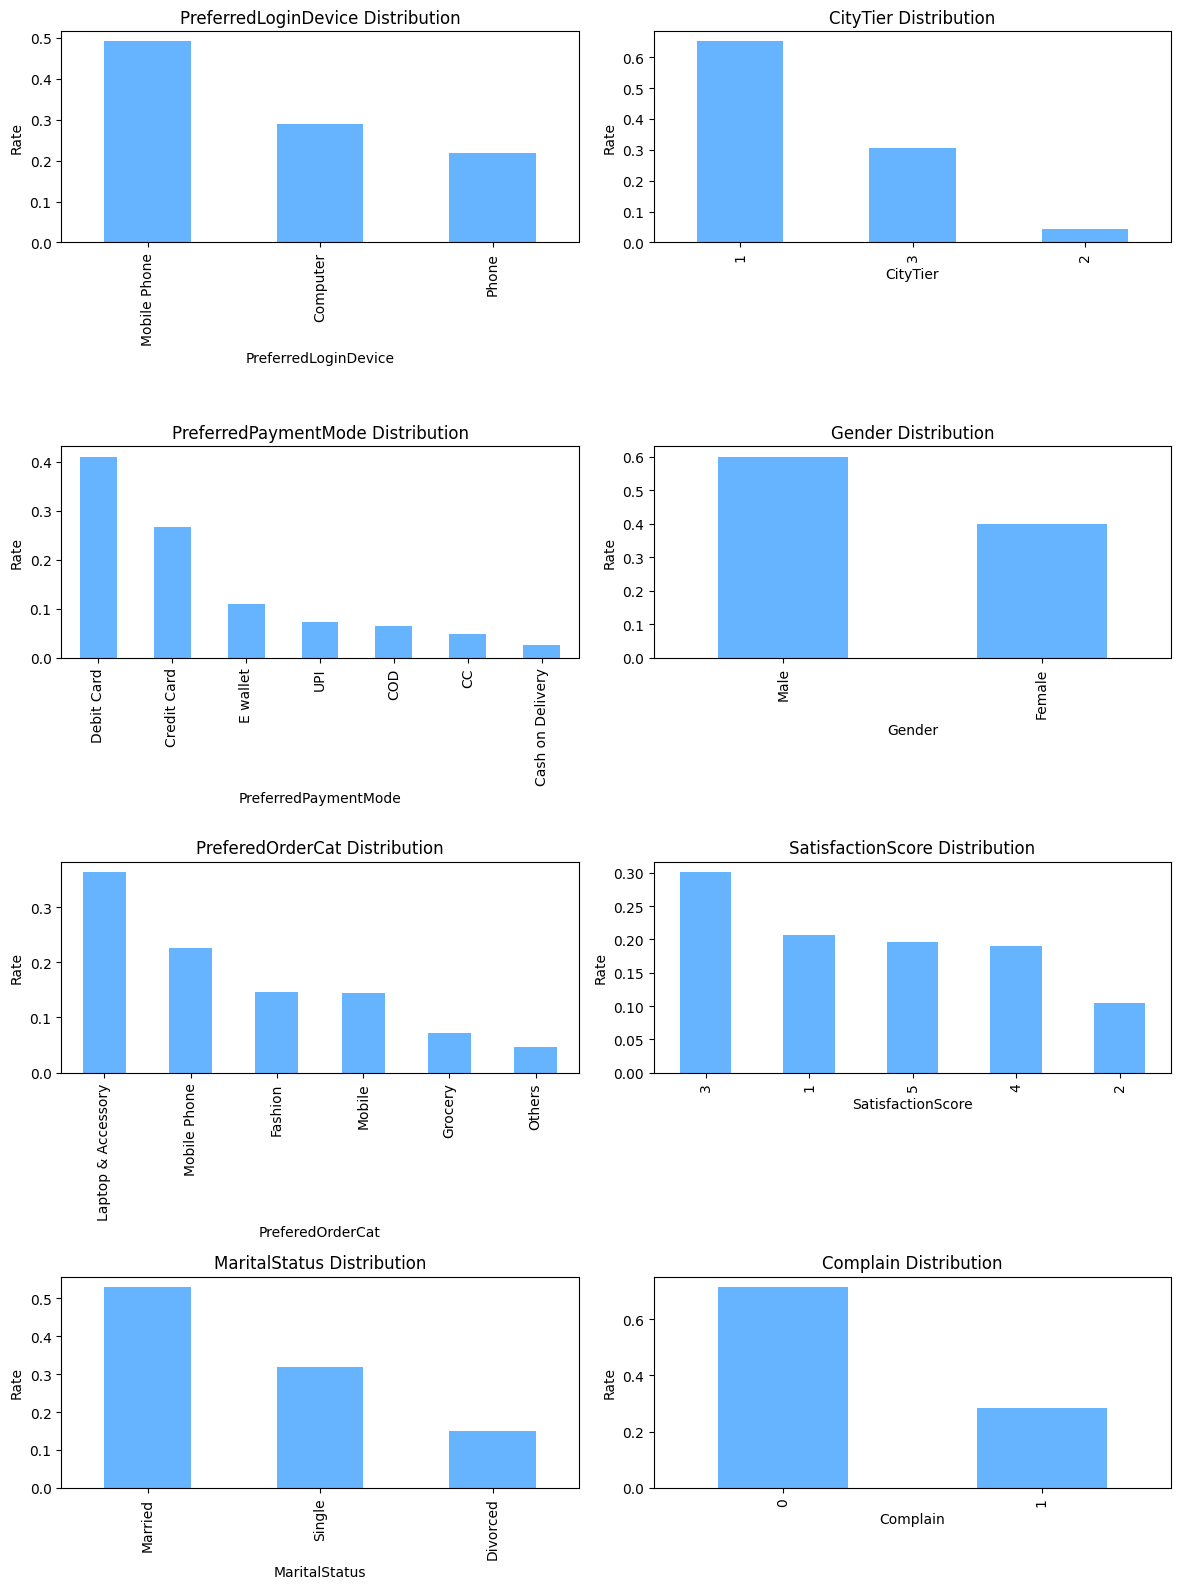

In [18]:
#分类变量 用户数占比


cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'Complain']


n_cols = 2  # 每行显示2张图
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # 自动计算行数

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
axes = axes.flatten()  # 展平成一维数组，方便循环

for i, col in enumerate(cat_cols):
    df[col].value_counts(normalize=True).plot(kind='bar', ax=axes[i], color="#66b3ff")
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_ylabel('Rate')
    axes[i].set_xlabel(col)

# 删除多余空白子图（如果总数不是行*列的整数倍）
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature.png", dpi=300, bbox_inches='tight')
plt.show()

For categorical features (e.g., Gender, CityTier, PreferredLoginDevice, PreferredPaymentMode, etc.), the bar plots reveal several key trends:

Demographics: The dataset is male-dominant (~60%) and primarily concentrated in Tier 1 cities, indicating stronger urban participation.

Platform Usage: The majority of users log in via mobile devices, reflecting the platform’s mobile-first user base.

Payment Preferences: Debit card and credit card are the most preferred payment modes, showing trust in traditional banking channels over newer methods like e-wallets or UPI.

Product Preferences: Most purchases fall within “Laptop & Accessories” and “Mobile Phone” categories, suggesting a tech-oriented shopping trend.

Customer Experience: The majority of users have medium satisfaction scores (2–3), with relatively fewer highly satisfied users, and only about one-third of users have ever lodged a complaint.

Marital Status: Most users are married, potentially indicating higher household-level consumption power.

### Insights

Analyzing feature distributions helps:

Detect data imbalance (e.g., gender, city tier) that might bias churn prediction models.

Identify feature scaling needs — for example, skewed numerical variables may require log transformation.

Reveal behavioral patterns — such as time spent on the app or device usage — that can inform segmentation and marketing strategies.

This exploratory analysis establishes a foundation for the subsequent feature engineering and churn correlation study.

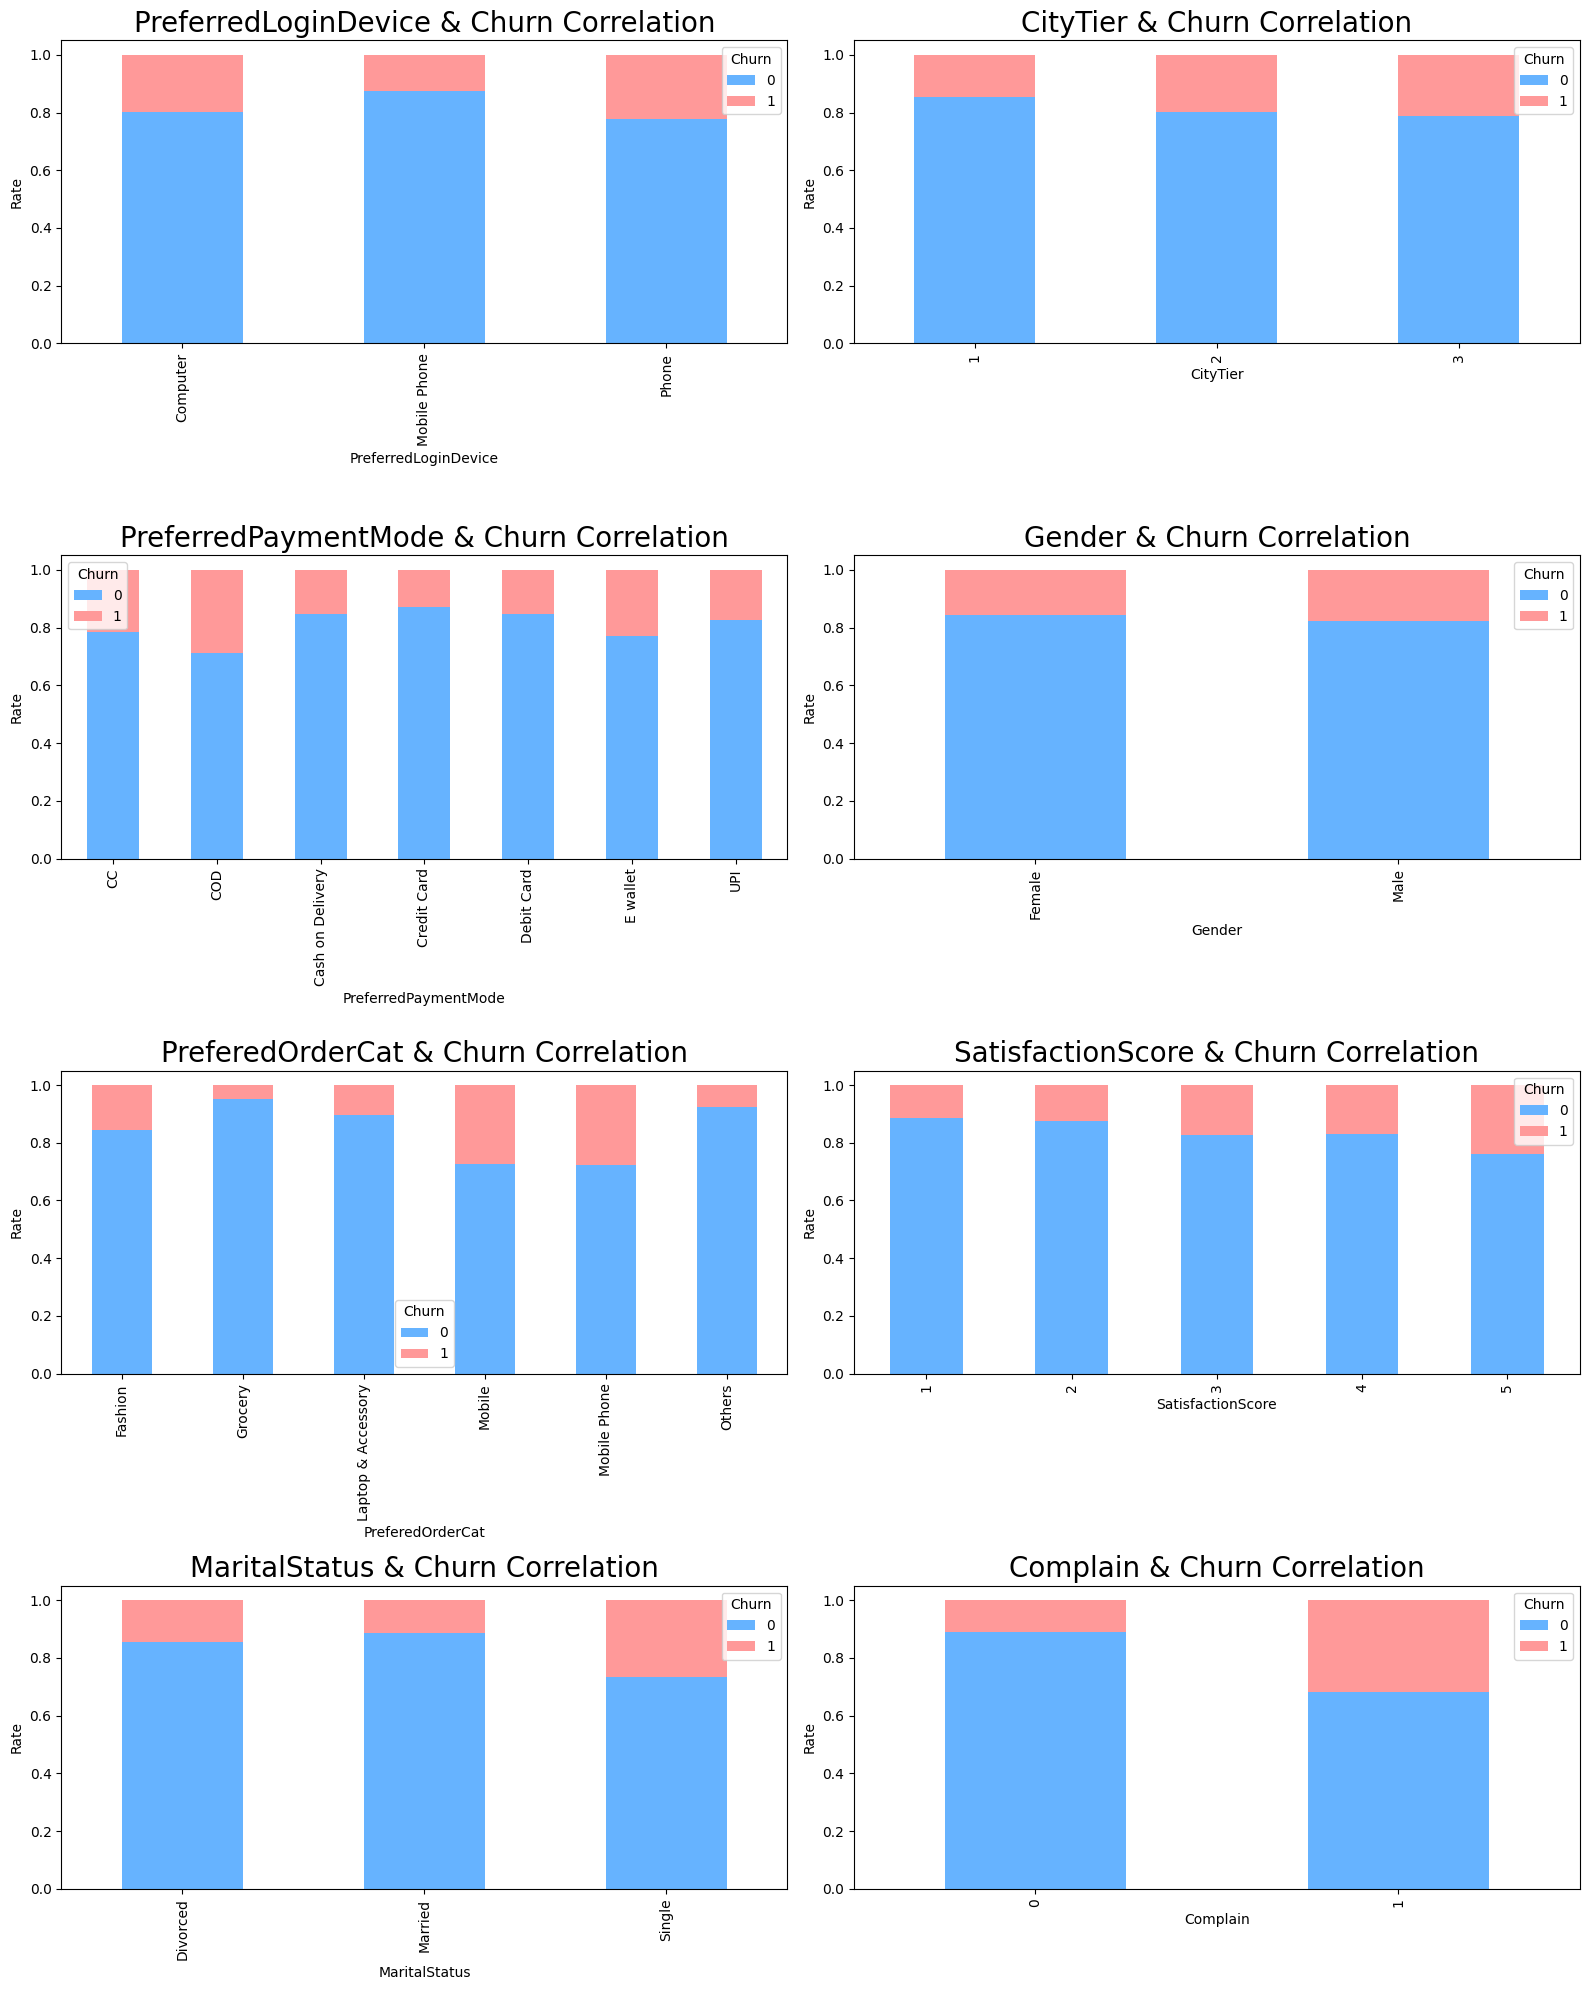

In [19]:
## 每个类别内部流失与未流失的比例
#pd.crosstab(a, b) 用于统计两个分类变量的 频数
n_cols = 2  
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  

# figsize
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()  

for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df["Churn"], normalize="index").plot(
        kind="bar", stacked=True, ax=axes[i], color=["#66b3ff", "#ff9999"]
    )
    axes[i].set_title(f'{col} & Churn Correlation', fontsize=20)
    axes[i].set_ylabel('Rate')
    axes[i].set_xlabel(col)

#  delete empty part
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature_churn.png", dpi=300, bbox_inches='tight')
plt.show()


We analyzed the relationship between categorical features and customer churn using stacked bar charts. Features such as SatisfactionScore and Complain show a strong correlation with churn, while others like CityTier or PreferredPaymentMode have weaker effects.

However, categorical variables were not directly used in the model since most machine learning algorithms require numerical inputs. These categorical variables need to be encoded first, and some of them might have been excluded later during feature selection due to low predictive power or high dimensionality.

# Feature Engineering

## Correlation Heatmap of Numeric Variables and Churn

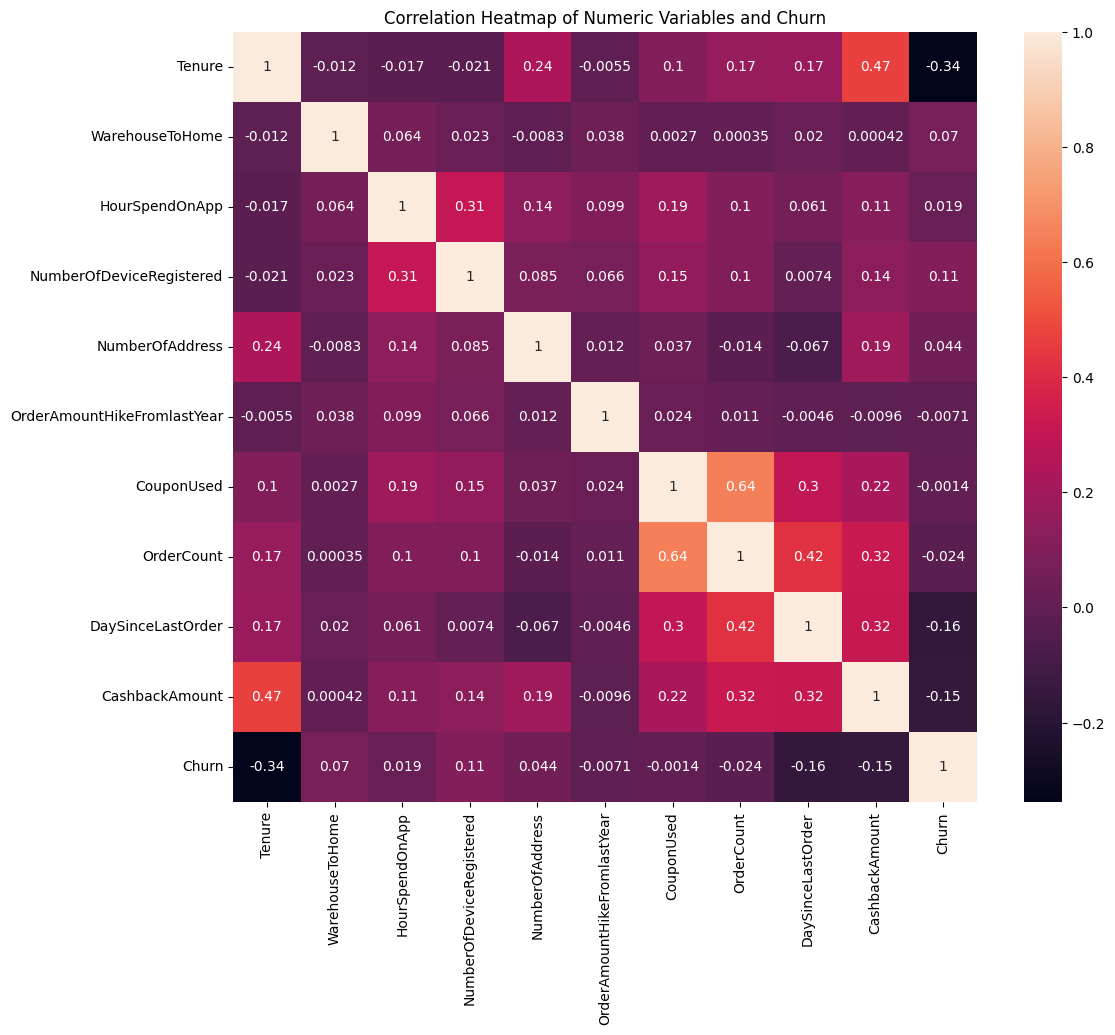

In [75]:
#相关性热力图
# 计算数值特征相关性矩阵
corr = df[num_cols + ['Churn']].corr()

# mask 掩码，先全 False
mask = np.zeros_like(corr, dtype=bool)

# 只保留“是否流失”这一列显示数字，其余位置不显示
mask[:, :-1] = True  # 除了最后一列，其他位置都 mask 掉

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap of Numeric Variables and Churn')
plt.show()

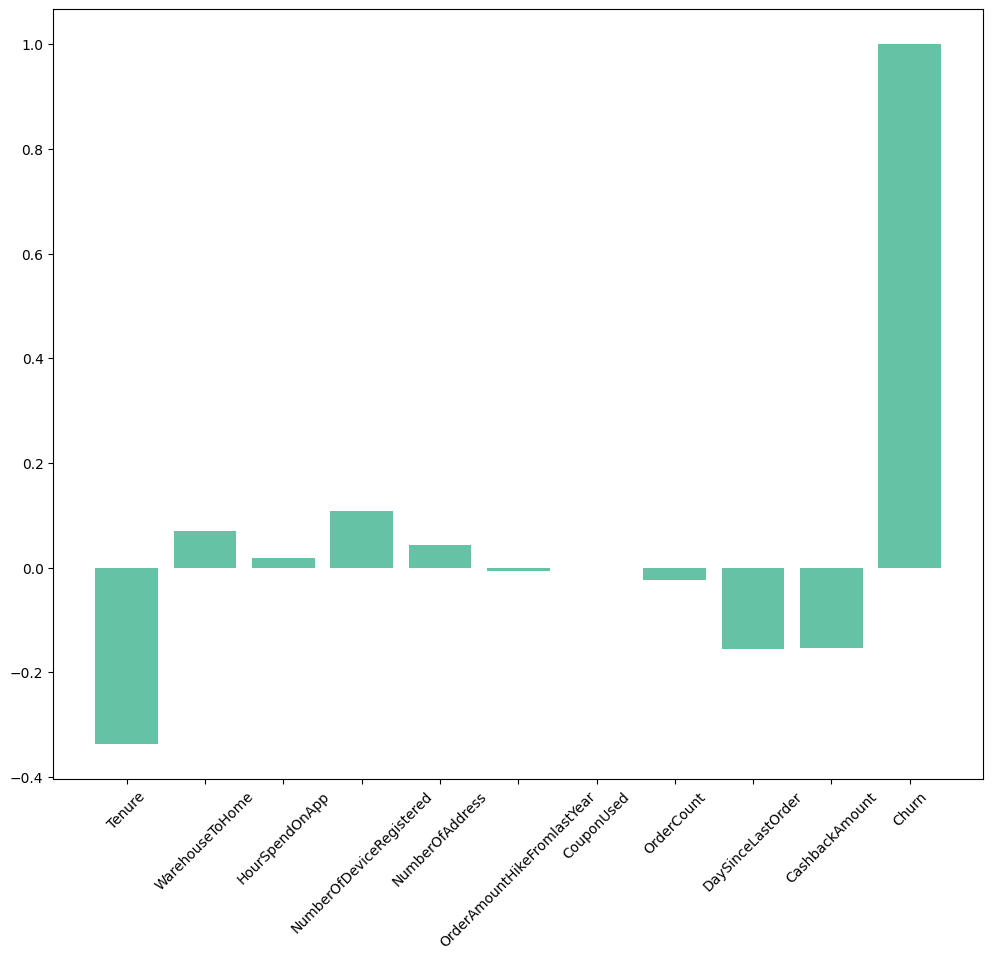

In [76]:
#最后一列单拎出来看
plt.figure(figsize=(12,10))
plt.bar(corr.index,corr['Churn'])
plt.xticks(rotation=45)
plt.show()

In [77]:
num_cols

['Tenure',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'NumberOfAddress',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

## Exploring Feature Importance and Churn Relationship

In [78]:
#找到相关性的特征
features=['Tenure','WarehouseToHome','NumberOfDeviceRegistered','NumberOfAddress','DaySinceLastOrder','CashbackAmount']
#From the above figure, we can see that 
#four variables are positively correlated with churn, 
#while six are negatively correlated. 
#Some correlations are close to zero, 
#and we may consider ignoring these near-zero features during the machine learning modeling stage.

In [79]:
#labels
labels=df["Churn"].copy()
#data
data=df[features].copy()

In [80]:
data.shape,labels.shape

((5630, 6), (5630,))

Since the categorical features require numerical encoding (e.g., label encoding or one-hot encoding) and their impact on churn appeared to be limited in the previous analysis, this study focuses on predictive modeling using only the numerical features.

In [81]:
'''
#处理类别型数据

#每列使用独立的 LabelEncoder，不会混淆不同列的类别。

from sklearn.preprocessing import LabelEncoder

# 保存每列对应的 LabelEncoder
encoders = {}

# 类别
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le 
'''

"\n#处理类别型数据\n\n#每列使用独立的 LabelEncoder，不会混淆不同列的类别。\n\nfrom sklearn.preprocessing import LabelEncoder\n\n# 保存每列对应的 LabelEncoder\nencoders = {}\n\n# 类别\ncategorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']\n\nfor col in categorical_cols:\n    le = LabelEncoder()\n    data[col] = le.fit_transform(data[col])\n    encoders[col] = le \n"

## Resampling

In [82]:

#solve the imbalanced data issue
# 进行重采样，解决数据集不平衡问题
def random_oversample(data, labels, random_state=42):
    
    #转为 DataFrame，方便操作
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(labels, pd.Series):
        labels = pd.Series(labels, name='label')
    
    df = pd.concat([data, labels], axis=1)
    
    #找到少数类和多数类
    class_counts = labels.value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()
    
    df_majority = df[df[labels.name] == majority_class]
    df_minority = df[df[labels.name] == minority_class]
    
    #复制少数类到与多数类数量相同
    df_minority_oversampled = df_minority.sample(len(df_majority), replace=True, random_state=random_state)
    
    #合并并打乱顺序
    df_balanced = pd.concat([df_majority, df_minority_oversampled], axis=0).sample(frac=1, random_state=random_state)
    
    #分离特征和标签
    data_balanced = df_balanced.drop(labels.name, axis=1)
    labels_balanced = df_balanced[labels.name]
    
    return data_balanced, labels_balanced

data_b, labels_b = random_oversample(data, labels)


In [84]:
#Standardize
scaler=StandardScaler()
data=scaler.fit_transform(data_b)
data.shape,labels_b.shape

((9364, 6), (9364,))

In [85]:
X_train,X_test,y_train,y_test=train_test_split(data,labels_b,test_size=0.2)

# Model Training and Comparison

## Logistic Regression

In [86]:
# parameter
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}
# model
lr = LogisticRegression()
# Gridsearch
gv_lr = GridSearchCV(estimator=lr, param_grid=param_grid,cv=5, scoring='accuracy', n_jobs=1)
gv_lr.fit(X_train, y_train)

#
print("Best param：", gv_lr.best_params_)
print("Best Acc：", gv_lr.best_score_)

Best param： {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Acc： 0.7419583683292199


In [87]:
best_lr = gv_lr.best_estimator_
y_pred = best_lr.predict(X_test)

print("Confusion Matrix：")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report：")
print(classification_report(y_test,y_pred))

Confusion Matrix：
[[634 275]
 [235 729]]

Classification report：
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       909
           1       0.73      0.76      0.74       964

    accuracy                           0.73      1873
   macro avg       0.73      0.73      0.73      1873
weighted avg       0.73      0.73      0.73      1873



## Decision Tree

In [88]:
#parameter
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# model
cl = DecisionTreeClassifier(random_state=42)
# 网格搜索
gv_cl = GridSearchCV(cl, param_grid, cv=5, scoring='accuracy', n_jobs=1)
gv_cl.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [89]:
print("Best param：", gv_cl.best_params_)
print("Best Acc：", gv_cl.best_score_)

Best param： {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Acc： 0.976772677111844


In [90]:
best_cl = gv_cl.best_estimator_

y_pred = best_cl.predict(X_test)

print("confusion Matrix：\n", confusion_matrix(y_test, y_pred))
print("Classification report：\n", classification_report(y_test, y_pred))

confusion Matrix：
 [[878  31]
 [  0 964]]
Classification report：
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       909
           1       0.97      1.00      0.98       964

    accuracy                           0.98      1873
   macro avg       0.98      0.98      0.98      1873
weighted avg       0.98      0.98      0.98      1873



[0.34600387 0.13986596 0.04964563 0.09480526 0.11174573 0.25793354]


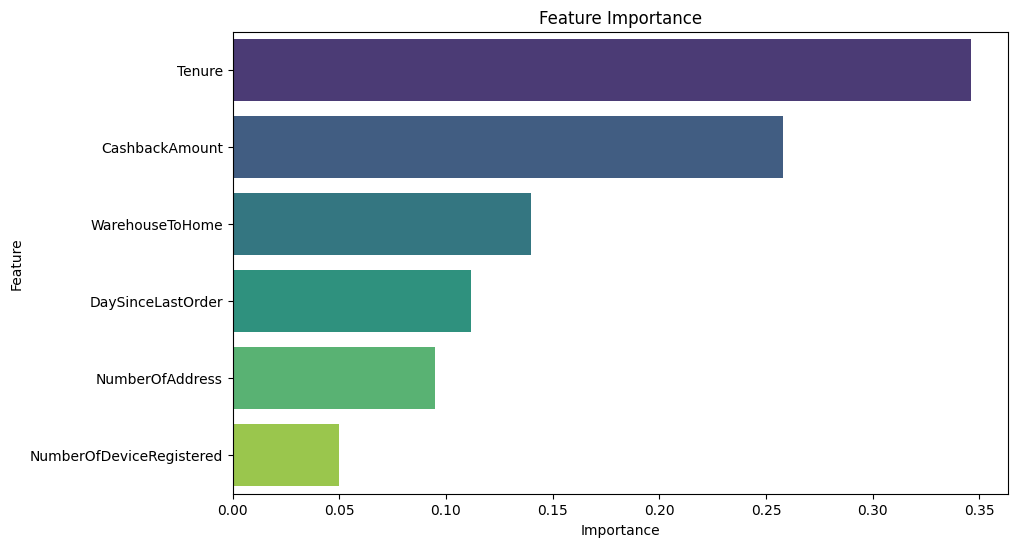

In [96]:
#feature importance

best_cl.feature_importances_

importances = best_cl.feature_importances_
print(importances)
feature_names = features

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
#sort order
feat_df = feat_df.sort_values(by='importance', ascending=False)

# visualize
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Random Forest

In [97]:
# Parameter
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# model
rfc = RandomForestClassifier(random_state=42)
# gridsearch
gv_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=1, scoring='accuracy')
gv_rfc.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [98]:
print("Best param：", gv_rfc.best_params_)
print("Best Acc：", gv_rfc.best_score_)

Best param： {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Acc： 0.9845148211847505


In [99]:
best_rfc = gv_rfc.best_estimator_
y_pred = best_rfc.predict(X_test)

print("Confusion Matrix：\n", confusion_matrix(y_test, y_pred))
print("Classification Report：\n", classification_report(y_test, y_pred))

Confusion Matrix：
 [[890  19]
 [  0 964]]
Classification Report：
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       909
           1       0.98      1.00      0.99       964

    accuracy                           0.99      1873
   macro avg       0.99      0.99      0.99      1873
weighted avg       0.99      0.99      0.99      1873



[0.37097823 0.12753464 0.0555764  0.0921376  0.10975865 0.24401447]


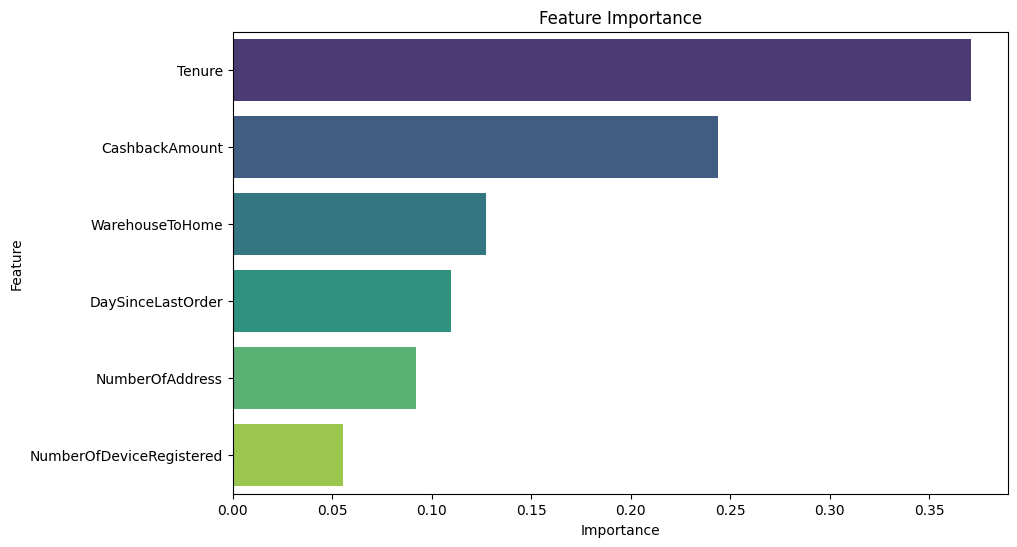

In [101]:
# Feature Importance

importances = best_rfc.feature_importances_
print(importances)
feature_names = features

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
#sort order
feat_df = feat_df.sort_values(by='importance', ascending=False)

# visualize
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## SVM

In [102]:

# parameter
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}
# model
svc = SVC()
# gridsearch
gv_svc = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1)
gv_svc.fit(X_train, y_train)


#result_param
print("Best Param：", gv_svc.best_params_)
print("Best Acc：", gv_svc.best_score_)

best_svc = gv_svc.best_estimator_

y_pred = best_svc.predict(X_test)

print("Confusion Matrix：\n", confusion_matrix(y_test, y_pred))
print("Classification Report：\n", classification_report(y_test, y_pred))

Best Param： {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Acc： 0.8514215529534152
Confusion Matrix：
 [[759 150]
 [112 852]]
Classification Report：
               precision    recall  f1-score   support

           0       0.87      0.83      0.85       909
           1       0.85      0.88      0.87       964

    accuracy                           0.86      1873
   macro avg       0.86      0.86      0.86      1873
weighted avg       0.86      0.86      0.86      1873



## XGBoost

In [103]:

# param
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
# model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# gridsearch
gv_xgb = GridSearchCV(estimator=xgb, param_grid=xgb_params, cv=5, scoring='accuracy', n_jobs=1,verbose=0)

gv_xgb.fit(X_train, y_train)


#param_result
print("Best param：", gv_xgb.best_params_)
print("Best Acc：", gv_xgb.best_score_)

Best param： {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best Acc： 0.9767722317771259


In [104]:

best_xgb = gv_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)

print("Confusion Matrix：\n", confusion_matrix(y_test, y_pred))
print("Classification report：\n", classification_report(y_test, y_pred))

Confusion Matrix：
 [[887  22]
 [  0 964]]
Classification report：
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       909
           1       0.98      1.00      0.99       964

    accuracy                           0.99      1873
   macro avg       0.99      0.99      0.99      1873
weighted avg       0.99      0.99      0.99      1873



[0.37097823 0.12753464 0.0555764  0.0921376  0.10975865 0.24401447]


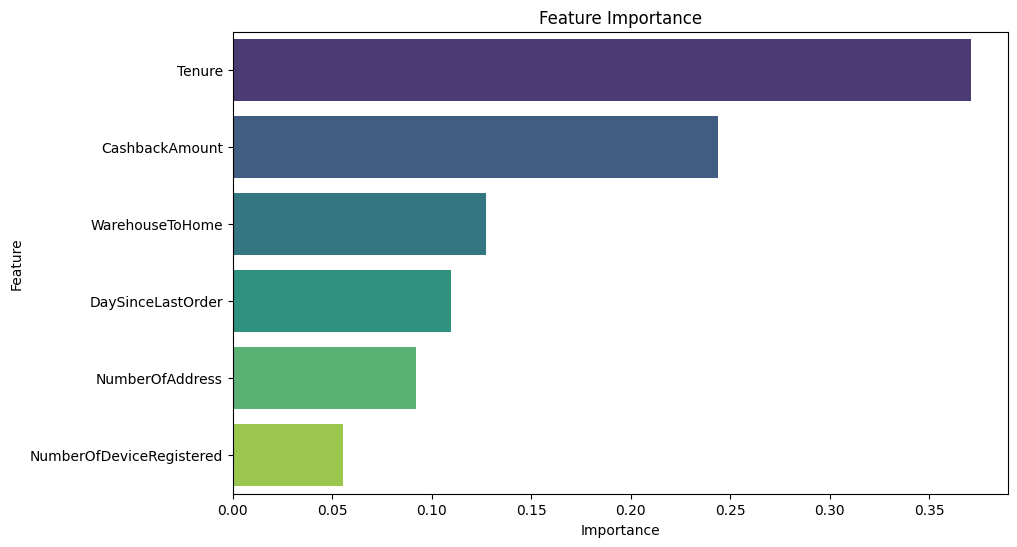

In [105]:
importance = best_xgb.feature_importances_
print(importances)
feature_names = features

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
#sort order
feat_df = feat_df.sort_values(by='importance', ascending=False)

# visualize
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Model Evaluation

Calculating the evaluation metrics.

In [106]:
# 定义一个函数将各个模型的性能指标计算出来
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }

In [111]:
# all models
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_cl,
    'Random Forest': best_rfc,
    'SVM': best_svc,
    'XGBoost': best_xgb
}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test)

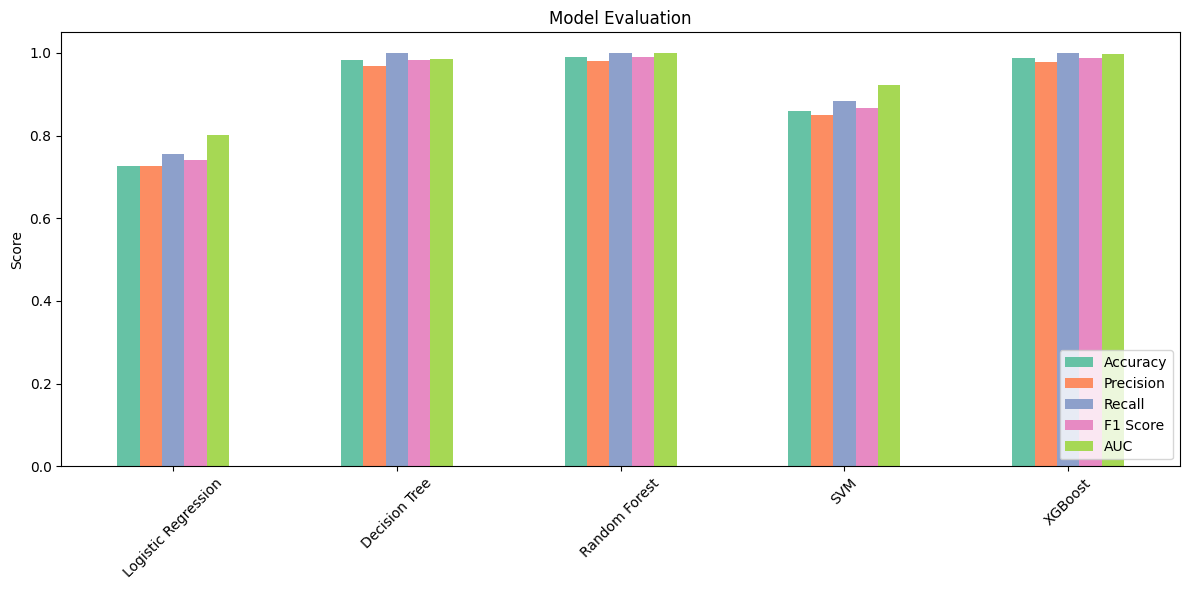

In [112]:
# 转为 DataFrame
results_df = pd.DataFrame(results).T  # 转置一下更方便看

# 可视化评估指标
results_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Evaluation")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

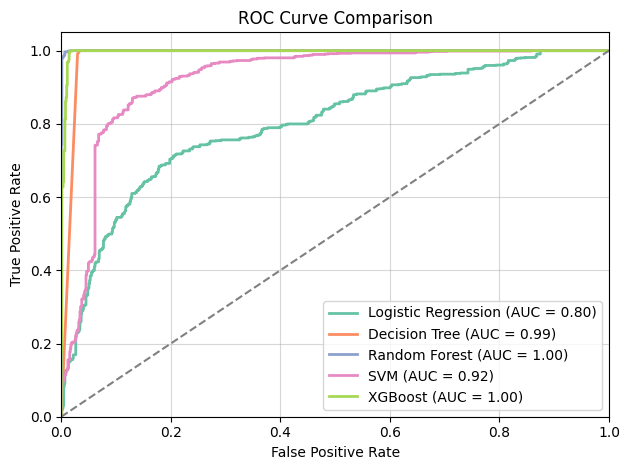

In [117]:
for name, model in models.items():
    # predict probability decision function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue  

    # ROC AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # plot
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

# 可视化
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

## Model comparison

| Model               | AUC  | Curve Position       | Interpretation                                                                                 |
| ------------------- | ---- | -------------------- | ---------------------------------------------------------------------------------------------- |
| Random Forest       | 1.00 | Near top-left corner | Theoretically a perfect classifier; may indicate potential data leakage or severe overfitting. |
| XGBoost             | 1.00 | Almost perfect       | Extremely high performance, slightly below RF; overfitting should still be considered.         |
| Decision Tree       | 0.99 | Close to top-left    | Performs very well, slightly lower than XGBoost.                                               |
| SVM                 | 0.92 | Slightly farther     | Good performance, but weaker than tree-based models.                                           |
| Logistic Regression | 0.80 | Farthest             | Lowest performance, but offers the best interpretability.                                      |


## Summary


Tree-based models (Random Forest, XGBoost, Decision Tree) outperform others in terms of AUC.

Random Forest achieves perfect AUC, but the unusually high value suggests checking for overfitting or data leakage.

XGBoost also performs exceptionally well, slightly below RF, and is often preferred for real-world predictive tasks due to better generalization.

SVM shows reasonable performance but is less effective than tree-based models.

Logistic Regression, while interpretable, has the weakest predictive performance.

Recommendation: Considering both performance and robustness, XGBoost is recommended as the primary model. Random Forest can be used as a benchmark, but extra care should be taken to verify that overfitting or data leakage is not influencing results.